# <center>MDSA D208 Predictive Modeling</center> 

## <center>Task 2 revision 2</center>

## <center>Justin Jordan</center>

## <center>3/26/2025</center>

## <center>WGU</center>



## Part I: Research Question

### A.  Describe the purpose of this data analysis by doing the following:

1.  Summarize one research question that is relevant to a real-world organizational situation captured in the data set you have selected and that you will answer using logistic regression.
    - What factors, if any, contribute to a customers churn?  I believe this is an important question to an organization as it costs 10 times more to acquire a new customer than to retain an existing one(Churn Data Consideration and Dictionary 2024).

2.  Define the goals of the data analysis.
    - The goal of this analysis is to better understand the relationships, if any, that contribute to a customers churn.  Logistic regression will be used to help identify any correlation to churn within the dataset that could be used to predict a customers churn.  Recommendations will be made based on findings to help reduce churn rate.    

## Part II: Method Justification

### B.  Describe logistic regression methods by doing the following:

1.  Summarize four assumptions of a logistic regression model.
    - Logistic regression model is a statistical technique that estimates the probability of a binary outcome.  Four assumptions of logistic regression are:
        - The dependent variable is binary for binary logistic regression; the dependent variable is ordinal for ordinal logistic regression
        - No Multicollinearity - Assumption that independent variables are not highly correlated with each other
        - No Outliers - Assumption that there are no extreme outliers that could influence the data
        - Large sample size - Assumption that there is sufficient sample size needed to ensure the model is accurate

2.  Describe two benefits of using Python or R in support of various phases of the analysis.
    - In this analysis, we will be using Python within a Jupyter notebook.  This gives us the ease and flexibility to have code and markdown cells in one easy to follow document.  The use of Python allows us to use multiple libraries for logistic regression that can handle, model and process data.  Python combined with Jupyter make it easy for not only implementing and reading code, but also creating the visual representations of the code all in one place making it easier to understand the data that is being worked with.  

3.  Explain why logistic regression is an appropriate technique to analyze the research question summarized in part I.
    -  Since Churn is a binary categorical variable, logistic regression will be used.  Logistic regression attempts to estimates the probability of a binary outcome by identifying correlations between the binary categorical dependent variable and multiple predictor variables.  Churn will be the dependent variable in this analysis since it contains yes or no values.   

## Part III: Data Preparation

### C.  Summarize the data preparation process for logistic regression by doing the following:

1.  Describe your data cleaning goals and the steps used to clean the data to achieve the goals that align with your research question including your annotated code.
- The goal is to have a clean data set that can be used for regression testing mentioned in part B above.  The following will be the steps taken in order to clean the data. 
    - needed packages will be imported into Python
    - pd.read_csv will be used to load data frame
    - .info() will be used to profile data frame
    - inspect data frame for duplicate values
    - .isnull().sum will be used to identify possible missing values
    - if missing values exist, they will be treated with imputation
    - identify outliers
    - Below is the code and output for section C1

In [51]:
# code for c1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# code for data frame
churn = pd.read_csv("C:/users/jjord/Documents/WGU/D208/PA2/rev3/churn_clean.csv")

# Profile of Data Frame
churn.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [52]:
# Missing values using isnull
churn.isnull().sum()

CaseOrder                  0
Customer_id                0
Interaction                0
UID                        0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
TimeZone                   0
Job                        0
Children                   0
Age                        0
Income                     0
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                     0
Contract                   0
Port_modem                 0
Tablet                     0
InternetService         2129
Phone                      0
Multiple                   0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport   

In [53]:
# look at unique values for InternetService
churn.InternetService.unique()

array(['Fiber Optic', 'DSL', nan], dtype=object)

In [54]:
# Impute nulls for InternetService
churn["InternetService"].fillna("No Internet Service", inplace=True)

In [55]:
# verify InternetService no longer has nulls
churn["InternetService"].isnull().sum()

0

Columns Zip, Lat, Lng currently are floats or ints. There are not quantitative so will change datatype to object. These values are not meant for any type of calculation. Since the rest of the data types for categorical are set to object, these will aslo.

In [56]:
obj_columns = ["Zip", "Lat", "Lng"]
churn[obj_columns] = churn[obj_columns].astype(object)

In [57]:
# rename item columns
churn.rename(
    columns={
        "Item1": "Timely_response",
        "Item2": "Timely_fixes",
        "Item3": "Timely_replacements",
        "Item4": "Reliability",
        "Item5": "Options",
        "Item6": "Respectful_response",
        "Item7": "Courteous_exchange",
        "Item8": "Active_listening",
    },
    inplace=True,
)

In [58]:
#profile df after clean
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  object 
 8   Lat                   10000 non-null  object 
 9   Lng                   10000 non-null  object 
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [59]:
# code for outliers.
churn.describe()

,CaseOrder,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Timely_response,Timely_fixes,Timely_replacements,Reliability,Options,Respectful_response,Courteous_exchange,Active_listening
count,10000.00000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,0.994200,0.398000,34.526188,172.624816,3392.341550,3.490800,3.505100,3.487000,3.497500,3.492900,3.497300,3.509500,3.495600
std,2886.89568,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,0.988466,0.635953,26.443063,42.943094,2185.294852,1.037797,1.034641,1.027977,1.025816,1.024819,1.033586,1.028502,1.028633
min,1.00000,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,0.000000,0.000000,1.000259,79.978860,155.506715,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,0.000000,0.000000,7.917694,139.979239,1236.470827,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,1.000000,0.000000,35.430507,167.484700,3279.536903,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,7500.25000,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,2.000000,1.000000,61.479795,200.734725,5586.141370,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,7.000000,6.000000,71.999280,290.160419,7158.981530,7.000000,7.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000


#### C2.
2.  Describe the dependent variable and all independent variables using summary statistics that are required to answer the research question, including a screenshot of the summary statistics output for each of these variables.
    - Below are the descriptive stats for the dependent variable and all independent variables being used.
        - Dependent Variable - Churn
        - Independent Variables - Tenure, Income, Age, MonthlyCharge, Outage_sec_perweek, Yearly_equip_failure, Bandwidth_GB_Year, InternetService, DeviceProtection, Phone, Contract, Gender

In [60]:
#c2 code descriptive stats for dependent variable Churn
churn['Churn'].describe()

count     10000
unique        2
top          No
freq       7350
Name: Churn, dtype: object

Descriptive stats for independent Variables - Tenure, Income, Age, MonthlyCharge, Outage_sec_perweek, Yearly_equip_failure, Bandwidth_GB_Year, InternetService, DeviceProtection, Phone, Contract, Gender

In [61]:
# descriptive stats for independent Variables 
churn['Tenure'].describe()


count    10000.000000
mean        34.526188
std         26.443063
min          1.000259
25%          7.917694
50%         35.430507
75%         61.479795
max         71.999280
Name: Tenure, dtype: float64

In [62]:
# descriptive stats for independent Variables
churn['Income'].describe()


count     10000.000000
mean      39806.926771
std       28199.916702
min         348.670000
25%       19224.717500
50%       33170.605000
75%       53246.170000
max      258900.700000
Name: Income, dtype: float64

In [63]:
# descriptive stats for independent Variables
churn['Age'].describe()


count    10000.000000
mean        53.078400
std         20.698882
min         18.000000
25%         35.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64

In [64]:
# descriptive stats for independent Variables
churn['MonthlyCharge'].describe()

count    10000.000000
mean       172.624816
std         42.943094
min         79.978860
25%        139.979239
50%        167.484700
75%        200.734725
max        290.160419
Name: MonthlyCharge, dtype: float64

In [65]:
# descriptive stats for independent Variables
churn['Outage_sec_perweek'].describe()


count    10000.000000
mean        10.001848
std          2.976019
min          0.099747
25%          8.018214
50%         10.018560
75%         11.969485
max         21.207230
Name: Outage_sec_perweek, dtype: float64

In [66]:
# descriptive stats for independent Variables
churn['Yearly_equip_failure'].describe()


count    10000.000000
mean         0.398000
std          0.635953
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          6.000000
Name: Yearly_equip_failure, dtype: float64

In [67]:
# descriptive stats for independent Variables
churn['Bandwidth_GB_Year'].describe()


count    10000.000000
mean      3392.341550
std       2185.294852
min        155.506715
25%       1236.470827
50%       3279.536903
75%       5586.141370
max       7158.981530
Name: Bandwidth_GB_Year, dtype: float64

In [68]:
# descriptive stats for independent Variables
print(churn['InternetService'].describe())
print()
print(churn['InternetService'].value_counts())


count           10000
unique              3
top       Fiber Optic
freq             4408
Name: InternetService, dtype: object

InternetService
Fiber Optic            4408
DSL                    3463
No Internet Service    2129
Name: count, dtype: int64


In [69]:
# descriptive stats for independent Variables
print(churn['DeviceProtection'].describe())
print()
print(churn['DeviceProtection'].value_counts())

count     10000
unique        2
top          No
freq       5614
Name: DeviceProtection, dtype: object

DeviceProtection
No     5614
Yes    4386
Name: count, dtype: int64


In [70]:
# descriptive stats for independent Variables
print(churn['Phone'].describe())
print()
print(churn['Phone'].value_counts())



count     10000
unique        2
top         Yes
freq       9067
Name: Phone, dtype: object

Phone
Yes    9067
No      933
Name: count, dtype: int64


In [71]:
# descriptive stats for independent Variables
print(churn['Contract'].describe())
print()
print(churn['Contract'].value_counts())

count              10000
unique                 3
top       Month-to-month
freq                5456
Name: Contract, dtype: object

Contract
Month-to-month    5456
Two Year          2442
One year          2102
Name: count, dtype: int64


In [72]:
# descriptive stats for independent Variables
print(churn['Gender'].describe())
print()
print(churn['Gender'].value_counts())

count      10000
unique         3
top       Female
freq        5025
Name: Gender, dtype: object

Gender
Female       5025
Male         4744
Nonbinary     231
Name: count, dtype: int64


#### C3.
3.  Generate univariate and bivariate visualizations of the distributions of the dependent and independent variables, including the dependent variable in your bivariate visualizations.
    - Below is the code and output for the univariate and bivariate visualizations for the dependent and independent variables.


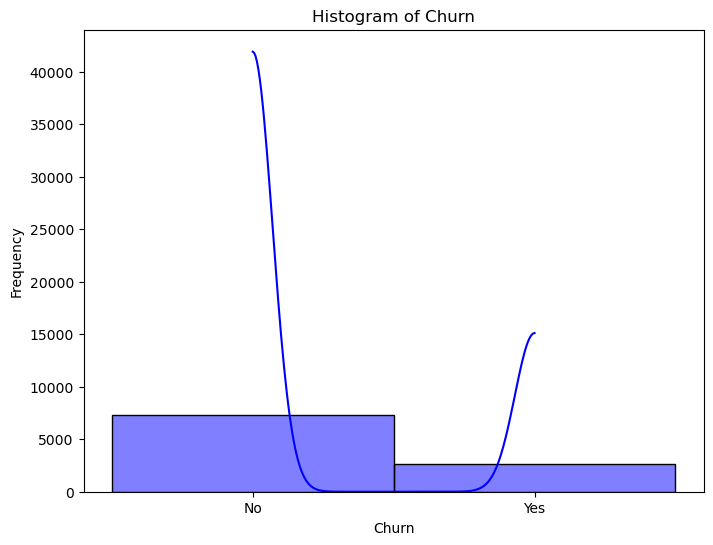

In [73]:
#c3 code visualizations for univariate
# Churn Histogram

plt.figure(figsize=(8,6))
sns.histplot(churn['Churn'], kde=True, bins=30, color='blue')
plt.title('Histogram of Churn')
plt.xlabel('Churn')
plt.ylabel('Frequency')
plt.show()

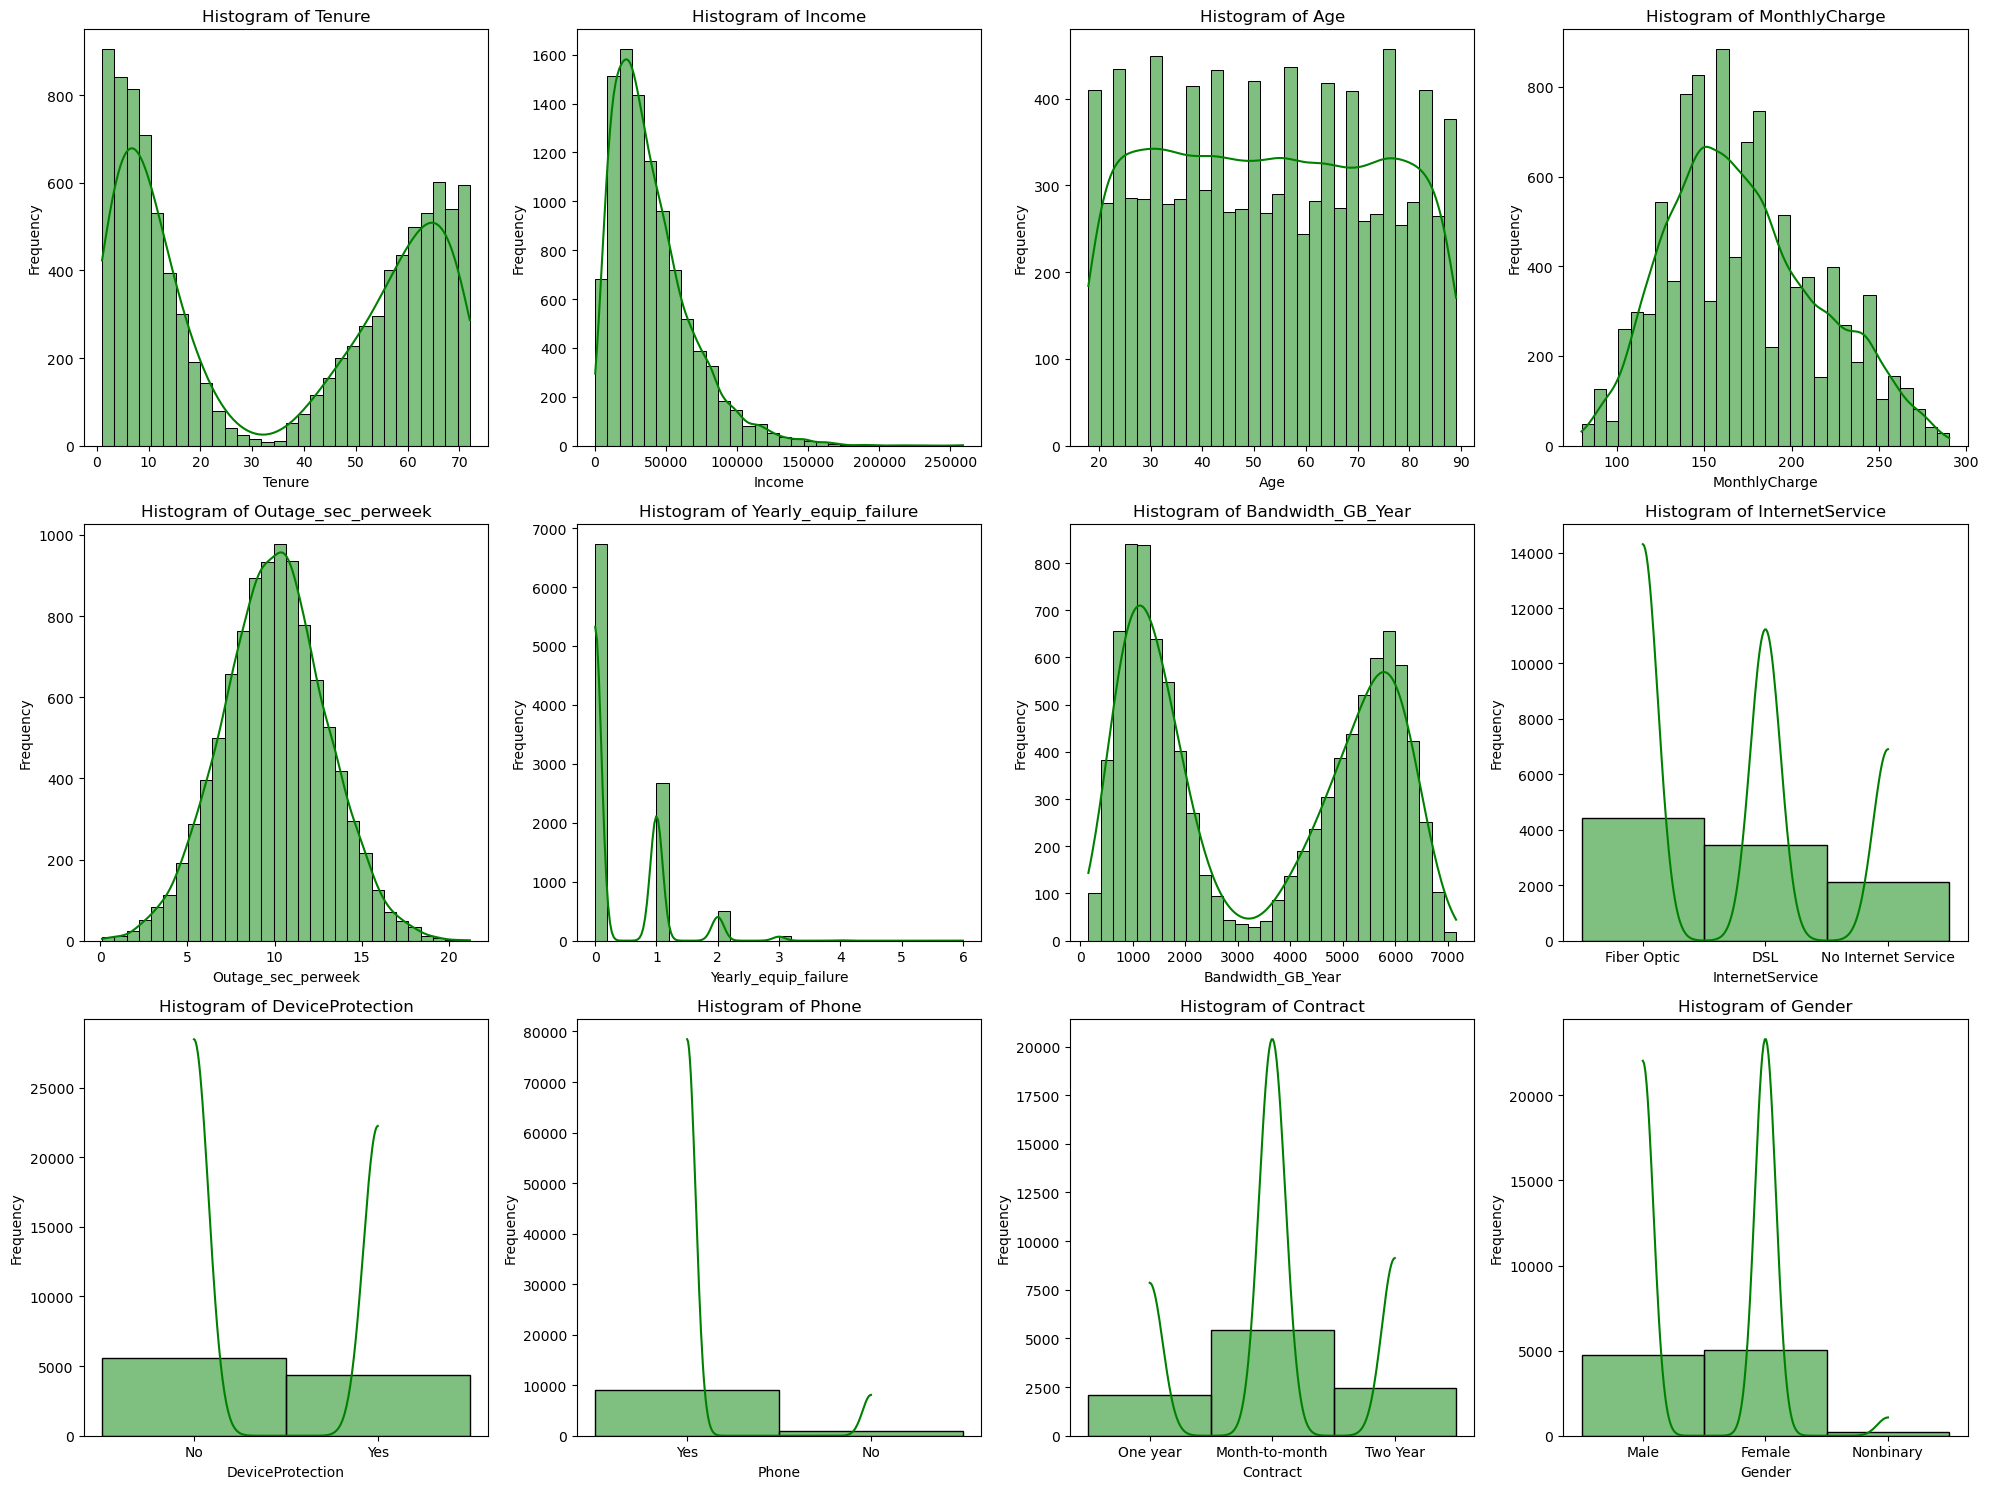

In [74]:
#c3 cont. code visualizations for univariate
#Independent variable histograms
plt.figure(figsize=(20, 15))
for x, col in enumerate(['Tenure', 'Income', 'Age', 'MonthlyCharge', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Bandwidth_GB_Year', 'InternetService', 'DeviceProtection', 'Phone', 'Contract', 'Gender'], 1):
    plt.subplot(3, 4, x)
    sns.histplot(churn[col], kde=True, bins=30, color='green')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

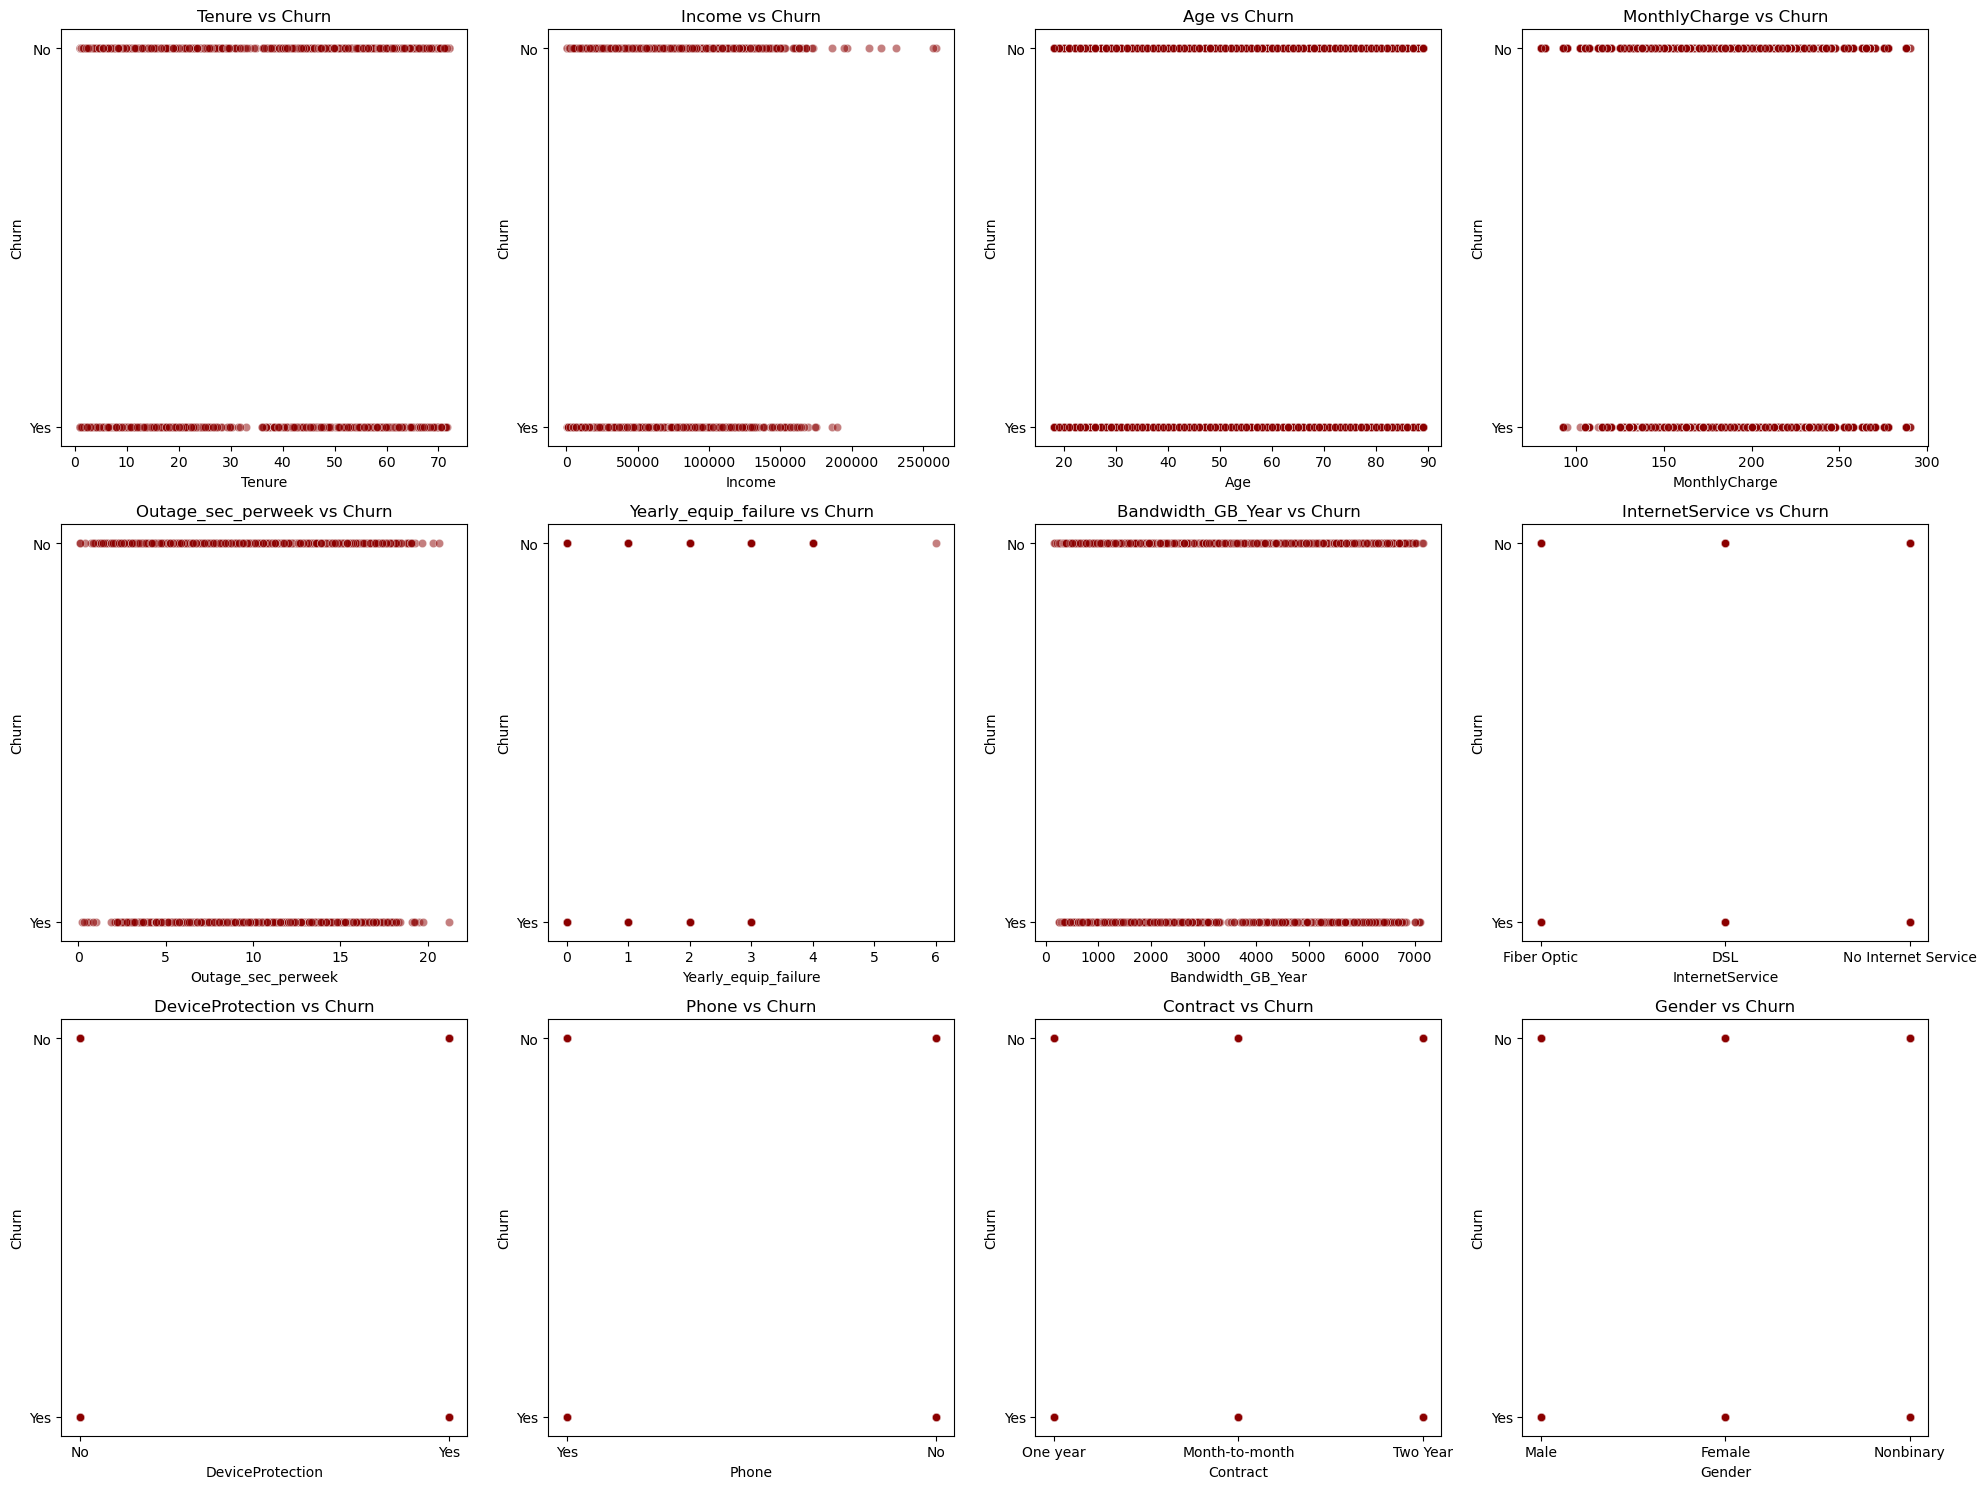

In [75]:
#code for bivariate visualizations for dependent variable(Churn) against each independent variable(Tenure, Income, Age, MonthlyCharge, Outage_sec_perweek, Yearly_equip_failure, Bandwidth_GB_Year, InternetService, DeviceProtection, Phone, Contract, Gender)

plt.figure(figsize=(20, 15))
for x, col in enumerate(['Tenure', 'Income', 'Age', 'MonthlyCharge', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Bandwidth_GB_Year', 'InternetService', 'DeviceProtection', 'Phone', 'Contract', 'Gender'], 1):
    plt.subplot(3, 4, x)
    sns.scatterplot(data=churn, x=col, y='Churn', color='darkred', alpha=0.5)
    plt.title(f'{col} vs Churn')
    plt.xlabel(col)
    plt.ylabel('Churn')
plt.tight_layout()
plt.show()

#### 4.  Describe your data transformation goals that align with your research question and the steps used to transform the data to achieve the goals, including the annotated code.
   - The goals for data transformation will be to one-hot-encode the categorical variables that will be transformed into numeric variables.  The numeric variables are stored in new columns, preserving the originals.  The dependent variable, Churn, will also encoded to binary.     

#### 5.  Provide the prepared data set as a CSV file.

Below is the code for both C4 & C5

In [ ]:
#c4 & c5 code
#package import
import statsmodels.api as sm


#create separate dataframes for continuous & categorical independent variables
churn_con = churn[['Tenure', 'Income', 'Age', 'MonthlyCharge', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Bandwidth_GB_Year']]
churn_cat = churn[['InternetService', 'DeviceProtection', 'Phone', 'Contract', 'Gender']]

#one hot encode categorical, dropping first level of each
churn_cat_encode = pd.get_dummies(churn_cat,drop_first=True)

#column concatenate
data = pd.concat([churn_con, churn_cat_encode], axis=1)

#dependent variable churn to binary
#churn_bin = churn['Churn'].map({'No': 0, 'Yes': 1})
#data['Churn'] = churn_bin

data['Churn'] = churn['Churn'].map({'No': 0, 'Yes': 1})

x = data.drop('Churn', axis=1)
y = data['Churn']








In [77]:
#c5 prepped data set
data.to_csv('prep_churn.csv', index=False)

In [ ]:
# d1
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Part IV: Model Comparison and Analysis

### D.  Compare an initial and a reduced logistic regression model by doing the following:

1.  Construct an initial logistic regression model from all independent variables that were identified in part C2.



In [78]:
#d1 code
from sklearn import linear_model
import statsmodels.api as sm

#create new dataframe for model
churn2 = pd.read_csv('prep_churn.csv')

churn2


,Tenure,Income,Age,MonthlyCharge,Outage_sec_perweek,Yearly_equip_failure,Bandwidth_GB_Year,InternetService_Fiber Optic,InternetService_No Internet Service,DeviceProtection_Yes,Phone_Yes,Contract_One year,Contract_Two Year,Gender_Male,Gender_Nonbinary,Churn
0,6.795513,28561.99,68,172.455519,7.978323,1,904.536110,True,False,False,True,True,False,True,False,0
1,1.156681,21704.77,27,242.632554,11.699080,1,800.982766,True,False,False,True,False,False,False,False,1
2,15.754144,9609.57,50,159.947583,10.752800,1,2054.706961,False,False,False,True,False,True,False,False,0
3,17.087227,18925.23,48,119.956840,14.913540,0,2164.579412,False,False,False,True,False,True,True,False,0
4,1.670972,40074.19,83,149.948316,8.147417,1,271.493436,True,False,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,68.197130,55723.74,23,159.979400,9.415935,0,6511.252601,False,False,True,True,False,False,True,False,0
9996,61.040370,34129.34,48,207.481100,6.740547,0,5695.951810,True,False,True,True,False,True,True,False,0
9997,47.416890,45983.43,48,169.974100,6.590911,0,4159.305799,True,False,False,True,False,False,False,False,0
9998,71.095600,16667.58,39,252.624000,12.071910,0,6468.456752,True,False,False,False,False,True,True,False,0


In [79]:

#initial model
x = churn2[['Tenure', 'Income', 'Age', 'MonthlyCharge', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Bandwidth_GB_Year', 'InternetService_Fiber Optic', 'InternetService_No Internet Service', 'DeviceProtection_Yes', 'Phone_Yes', 'Contract_One year', 'Contract_Two Year', 'Gender_Male', 'Gender_Nonbinary']].assign(intercept=1)
y = churn2[['Churn']]
y = y.values.ravel()

#model setup
#fit logistic regression model
lr = linear_model.LogisticRegression(solver='lbfgs', max_iter=10000)
lr.fit(x, y)

logit_model = sm.Logit(y.astype(float), x.astype(float))
result = logit_model.fit()
print(result.summary())



Optimization terminated successfully.
         Current function value: 0.233163
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9984
Method:                           MLE   Df Model:                           15
Date:                Wed, 26 Mar 2025   Pseudo R-squ.:                  0.5968
Time:                        19:20:04   Log-Likelihood:                -2331.6
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Tenure                                 -0.2281      0.034 

#### D2
2.  Justify a statistically based feature selection procedure or a model evaluation metric to reduce the initial model in a way that aligns with the research question.
    - Backward elimination will be used to remove variables that are insignificant based on their p-values.  P-values with a significance level higher than .05 will be removed.  By doing this, it will remove variables that do not have a significant impact on the dependent variable.  

3.  Provide a reduced logistic regression model that follows the feature selection or model evaluation process in part D2, including a screenshot of the output for each model.
    - Code for D3 is below

In [80]:
#code for d2 & d3


#initial model
x = churn2[['Tenure', 'Income', 'Age', 'MonthlyCharge', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Bandwidth_GB_Year', 'InternetService_Fiber Optic', 'InternetService_No Internet Service', 'DeviceProtection_Yes', 'Phone_Yes', 'Contract_One year', 'Contract_Two Year', 'Gender_Male', 'Gender_Nonbinary']].assign(intercept=1)
y = churn2[['Churn']]
y = y.values.ravel()

#model setup
#fit logistic regression model
lr = linear_model.LogisticRegression(solver='lbfgs', max_iter=10000)
lr.fit(x, y)

logit_model = sm.Logit(y.astype(float), x.astype(float))
result = logit_model.fit()
print(result.summary())





Optimization terminated successfully.
         Current function value: 0.233163
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9984
Method:                           MLE   Df Model:                           15
Date:                Wed, 26 Mar 2025   Pseudo R-squ.:                  0.5968
Time:                        19:20:45   Log-Likelihood:                -2331.6
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Tenure                                 -0.2281      0.034 

In [81]:
#code for d3
#variables
x = churn2[['Tenure', 'Income', 'Age', 'MonthlyCharge', 'Outage_sec_perweek', 'Yearly_equip_failure', 'Bandwidth_GB_Year', 'InternetService_Fiber Optic', 'InternetService_No Internet Service', 'DeviceProtection_Yes', 'Phone_Yes', 'Contract_One year', 'Contract_Two Year', 'Gender_Male', 'Gender_Nonbinary']].assign(intercept=1)
y = churn2[['Churn']]
y = y.values.ravel()

#model setup
#fit logistic regression model
lr = linear_model.LogisticRegression(solver='lbfgs', max_iter=10000)
lr.fit(x, y)

logit_model = sm.Logit(y.astype(float), x.astype(float))
result = logit_model.fit()

#remove variables with p value > 0.05
while True:
    max_p_value = result.pvalues.drop('intercept').max()  
    if max_p_value > 0.05:
        variable_to_remove = result.pvalues.idxmax()  
        x = x.drop(variable_to_remove, axis=1)  
        logit_model = sm.Logit(y.astype(float), x.astype(float))
        result = logit_model.fit()
    else:
        break

# Summary 
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.233163
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.233163
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.233172
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.233181
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.233194
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.233214
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.233392
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9990
Method:                           MLE   Df Model:

### E.  Analyze the data set using your reduced logistic regression model by doing the following:

1.  Explain your data analysis process by comparing the initial logistic regression model and reduced logistic regression model, including the following element:

•    Backward elimination was used to remove variables that are insignificant based on their p-values.  The model evaluation metric used was Pseudo R squared.  In both models, the Pseudo R squared value and the Log-Likelihood were almost the same.  The Pseudo R squared value barely dropped but the Log-Likelihood value barely increased on the reduced model.  With the values being so similar between the models, even though 6 less variables were used, it is safe to say the reduced model is more efficient.  P-values with a significance level higher than .05 were removed.      
  

- Original Model Pseudo R squared value = .5968
- Reduced Model Pseudo R squared value = .5964

- Original Model Log-Likelihood value = -2331.6
- Reduced Model Log-Likelihood value = -2333.9



#### E2
2.   Provide the output and all calculations of the analysis you performed, including the following elements for your reduced logistic regression model:

•   confusion matrix

•   accuracy calculation

3.  Provide an executable error-free copy of the code used to support the implementation of the logistic regression models using a Python or R file.

- below is the code for E2 & E3

In [82]:
#code for e2 & e3
#calculations are in sections d2 & d3

#confusion matrix and accuracy calculation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

x_const = sm.add_constant(x).astype(float)
y_predict_prob = result.predict(x_const)

y_predict = (y_predict_prob > 0.5).astype(int)

con_mat = confusion_matrix(y, y_predict)
print("Confusion Matrix:")
print(con_mat)

print('----------------')

accuracy = accuracy_score(y, y_predict)
print(f"Accuracy: {accuracy:.4f}")


Confusion Matrix:
[[6884  466]
 [ 568 2082]]
----------------
Accuracy: 0.8966


## Part V: Data Summary and Implications

### F.  Summarize your findings and assumptions by doing the following:

1.  Discuss the results of your data analysis, including the following elements:

•   a regression equation for the reduced model
    - Y = -6.4531 + -0.2480(Tenure) + .0063(Age) + .0490(MonthlyCharge) + .0017(Bandwidth_BG_Year) + -1.5281(InternetService_Fiber Optic) + -0.3154(DeviceProtection_Yes) + -0.2508(Phone_Yes) + -3.1564(Contract_One year) + -3.2773(Contract_Two Year)

•   an interpretation of the coefficients of the reduced model
    - Interpretation has been done for the reduced model by calculating thd odds ratio for each of the coefficients below.  


In [83]:
#interp coef

churn_odds = pd.DataFrame(np.exp(result.params) * 100 -100, columns = ['Odds Ratio %'])
churn_odds

,Odds Ratio %
Tenure,-21.962116
Age,0.633297
MonthlyCharge,5.019687
Bandwidth_GB_Year,0.170030
InternetService_Fiber Optic,-78.305243
DeviceProtection_Yes,-27.047843
Phone_Yes,-22.180493
Contract_One year,-95.741960
Contract_Two Year,-96.226820
intercept,-99.842434


- Holding all other explanatory varibales constant, Tenure is a 21.96% decrease in the relative chance to churn.
- Holding all other explanatory variables constant, Age is a .63% increase in the relative chance to churn.
- Holding all other explanatory variables constant, MonthlyCharge is a 5.01% increase in the relative chance to churn. 
- Holding all other explanatory variables constant, Bandwidth_GB_Year is a .17% increase in the relative chance to churn. 
- Holding all other explanatory variables constant, a person who has InternetService_Fiber Optic is 78.31% less likely to churn versus someone who doesn't have Fiber Optic. 
- Holding all other explanatory variables constant, a person who has DeviceProtection_Yes is 27.05% less likely to churn versus someone who doesn't have Device Protection.
- Holding all other explanatory variables constant, a person who has Contract_One Year is 95.74% less likely to churn versus someone who doesn't have a One Year Contract.
- Holding all other explanatory variables constant, a person who has Contract_Two Year is 96.23% less likely to churn versus someone who doesn't have a Two Year Contract.
- If all other values are zero, a person is 99.84% less likely to churn. 


  

•   the statistical and practical significance of the reduced model
- With the Pseudo R squared value being .5964, it suggests that model only explains 59.64% of the variance.  The Pseudo R squared shows there is a variance in the dependent variable not explained by the independent variables used.  The statistical significance of the model is mediocre and would prefer to see a higher Pseudo R squared value showing greater statistical significance even though the regression equation shows some variables that correlate to a higher probability of churn.  

- There practical significance of the reduced model is also medicore. The relationship between the vairables suggest a mediocre variance based upon the Pseudo R squared value even though the accuracy score was .8966 and some variables within the regression equation correlate to a higher probability of churn but some variables within the regression equation correlate to a lower probability of churn.


•   the limitations of the data analysis
-  There are several limitations with this analysis.  First, the standard error can be large.  Second, regression models are limited by correlation does not equal causation.  The model indicates varaibles that are most correlated with Churn but it cannot be said that just because a customer uses more Bandwidth_GB_year that they are more likely to churn.  Lastly, with the Pseudo R squared value being mediocre, it would also be considered a limitation.  Also, the analysis assumes linearity, absence of multicollinearity, and no outliers. Violations of these assumptions would impact the model's accuracy.     

2.  Recommend a course of action based on your results.
- I would recommend that the data be furhter explored with different variables to see if a customers churn can be predicted .  Based on the variables used, there is not enough variance here to accuratly predict churn.  It would benefit the company to do additional analysis with different independent variables to better determine if a customers churn can be predicted.  After further analysis has been done, the company can then make an informed decision on the research question.  

## Part VI: Demonstration

### G.  Provide a Panopto video recording that includes the presenter and a vocalized demonstration of the functionality of the code used for the analysis of the programming environment, including the following elements:

•   an identification of the version of the programming environment

•   a comparison of the initial logistic regression model you used and the reduced logistic regression model you used in your analysis

•   an interpretation of the coefficients of the reduced model

- https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=757c23c2-fa10-4890-b48f-b2ac017ea56a

### H.  List the web sources used to acquire data or segments of third-party code to support the application. Ensure the web sources are reliable.


### I.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
    WGU. (n.d.). Churn Data Consideration and Dictionary. Data Files and Associated Dictionary Files. https://access.wgu.edu/ASP3/aap/content/d9rkejv84kd9rk30fi2l.zip 